In [1]:
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
import torch 
import torch.nn as nn

In [2]:
Nx= 200
#cfl= 0.2
tmax = 1 # time 0 ~ 1

#viscosity_coeff = (0.01/math.pi)
viscosity_coeff = 0.02

x = np.linspace(-1,1, 200)

#t = 0  , I.C
u = -1*np.sin(math.pi * x)
dx = abs(x[1]-x[0])

dt = 0.002# cfl * dx / np.max(np.abs(u))

nt = int(tmax/ dt) #+ 1

uf = np.zeros((nt,Nx))
uf[0, :] = u

print(nt)
print(dt)
print(nt * dt, tmax )

500
0.002
1.0 1


In [3]:
def f(u):
    y = 0.5 * u**2
    yp = u
    return y, yp

In [4]:
def minmod(a,b):
    return 0.5 * (np.sign(a)+ np.sign(b)) * np.minimum(np.abs(a), np.abs(b))

In [5]:
def RHS(u, dx, viscosity_coeff):
    # 1. Compute the diffusion term (central difference)
    diffusion_term = viscosity_coeff * (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / dx**2

    # 2. Compute limited slope (minmod)
    du_forward  = (np.roll(u, -1) - u) / dx
    du_backward = (u - np.roll(u, 1)) / dx
    ux = minmod(du_backward, du_forward)

    # 3. Reconstruct left and right states at i+1/2
    uL = u + 0.5 * dx * ux       # left-biased at i+1/2
    uR = np.roll(u, -1) - 0.5 * dx * np.roll(ux, -1)  # right-biased at i+1/2

    # 4. Compute physical flux and wave speed
    fL, fpL = f(uL)
    fR, fpR = f(uR)
    a = np.maximum(np.abs(fpL), np.abs(fpR))

    # 5. Compute numerical flux H at i+1/2
    H = 0.5 * (fL + fR - a * (uR - uL))

    # 6. Compute convection term: - (H_{i+1/2} - H_{i-1/2}) / dx
    conv_term = -(H - np.roll(H, 1)) / dx

    return conv_term + diffusion_term

In [6]:
for i in range(1, nt):
    u1 = u + dt * RHS(u,dx,viscosity_coeff)
    u = 0.5 * u + 0.5 * (u1 + dt * RHS(u1, dx,viscosity_coeff))
    uf[i, :] = u

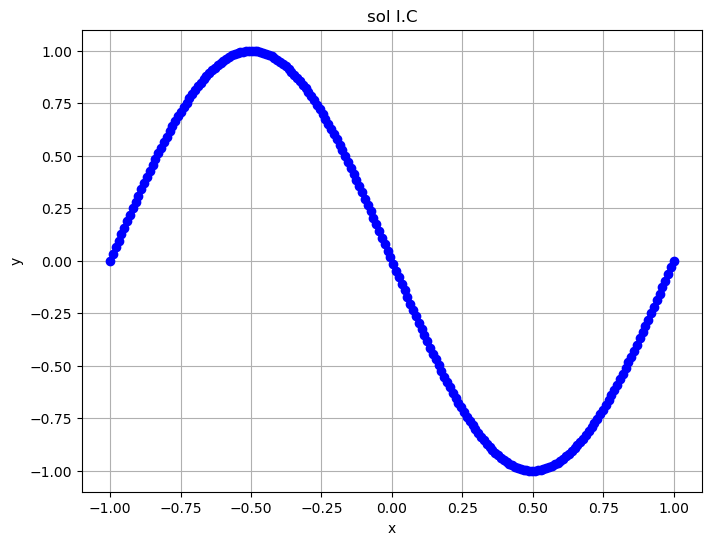

In [7]:
plt.figure(figsize=(8,6))
plt.plot(x, uf[0], '-o', color = 'b')
plt.title("sol I.C")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

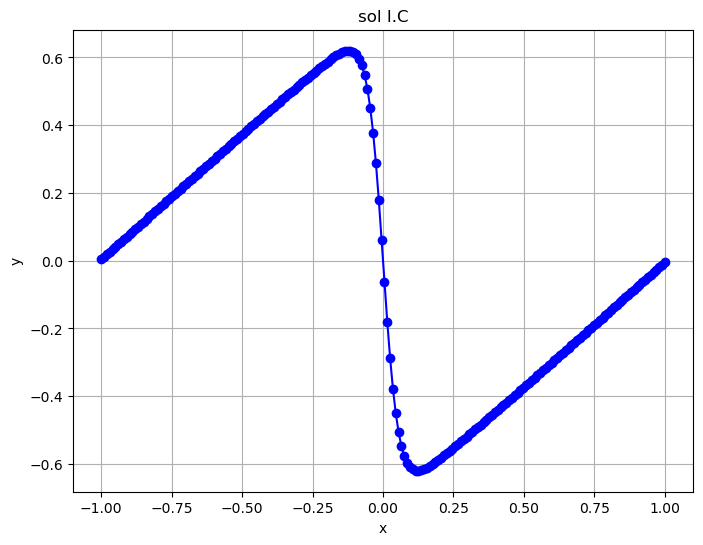

In [8]:
plt.figure(figsize=(8,6))
plt.plot(x, uf[-1], '-o', color = 'b')
plt.title("sol I.C")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

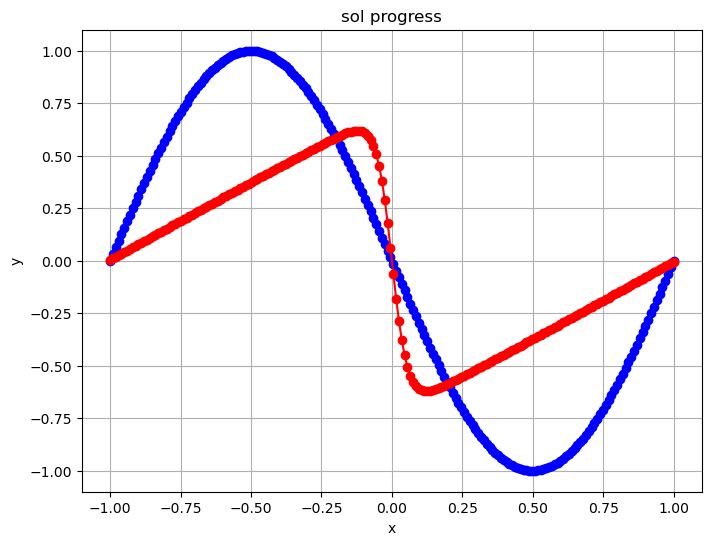

In [9]:
plt.figure(figsize=(8,6))
plt.plot(x, uf[0], '-o', color = 'b')
plt.plot(x, uf[-1], '-o', color = 'r')
plt.title("sol progress")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

In [10]:
uf

array([[ 1.22464680e-16,  3.15685498e-02,  6.31056313e-02, ...,
        -6.31056313e-02, -3.15685498e-02, -1.22464680e-16],
       [ 5.00078481e-03,  3.38734899e-02,  6.26522538e-02, ...,
        -6.26522538e-02, -3.38734899e-02, -5.00078481e-03],
       [ 7.95653150e-03,  3.53627996e-02,  6.28300146e-02, ...,
        -6.28300146e-02, -3.53627996e-02, -7.95653150e-03],
       ...,
       [ 3.74384886e-03,  1.12315041e-02,  1.87190316e-02, ...,
        -1.87190316e-02, -1.12315041e-02, -3.74384886e-03],
       [ 3.73826190e-03,  1.12147434e-02,  1.86910980e-02, ...,
        -1.86910980e-02, -1.12147434e-02, -3.73826190e-03],
       [ 3.73269163e-03,  1.11980328e-02,  1.86632477e-02, ...,
        -1.86632477e-02, -1.11980328e-02, -3.73269163e-03]])

In [11]:
tf = np.linspace(0,1, nt)

In [12]:
#tf

In [13]:
xf = x

In [14]:
#xf

In [36]:
tf_tensor = torch.tensor(tf)
xf_tensor = torch.tensor(xf)

print(len(tf_tensor))
print(len(xf_tensor))

combined_tensor_x_train = torch.empty((len(tf)*len(xf), 2), dtype= torch.float32)

index = 0
for i in range(len(tf)):
    for j in range(len(xf)):
        combined_tensor_x_train[index][0] = xf_tensor[j]
        combined_tensor_x_train[index][1] = tf_tensor[i]
        index= index +1
        
print(len(combined_tensor_x_train))

'''
import torch

# assume tf and xf are lists or 1D tensors
tf_tensor = torch.tensor(tf, dtype=torch.float32)
xf_tensor = torch.tensor(xf, dtype=torch.float32)

# create meshgrid
XF, TF = torch.meshgrid(xf_tensor, tf_tensor, indexing='ij')  # shape: (len(xf), len(tf))

# flatten and stack into combined 2D tensor
combined_tensor_x_train = torch.stack([XF.flatten(), TF.flatten()], dim=1)

print(combined_tensor_x_train.shape)
'''

500
200
100000


"\nimport torch\n\n# assume tf and xf are lists or 1D tensors\ntf_tensor = torch.tensor(tf, dtype=torch.float32)\nxf_tensor = torch.tensor(xf, dtype=torch.float32)\n\n# create meshgrid\nXF, TF = torch.meshgrid(xf_tensor, tf_tensor, indexing='ij')  # shape: (len(xf), len(tf))\n\n# flatten and stack into combined 2D tensor\ncombined_tensor_x_train = torch.stack([XF.flatten(), TF.flatten()], dim=1)\n\nprint(combined_tensor_x_train.shape)\n"

In [ ]:
tf_tensor = torch.tensor(tf, dtype=torch.float32)
xf_tensor = torch.tensor(xf, dtype=torch.float32)

combined_tensor_x_train = torch.cartesian_prod(xf_tensor, tf_tensor)

print(combined_tensor_x_train.shape)

In [16]:
#tf_tensor
#xf_tensor
combined_tensor_x_train
#len(combined_tensor_x_train)

tensor([[-1.0000,  0.0000],
        [-0.9899,  0.0000],
        [-0.9799,  0.0000],
        ...,
        [ 0.9799,  1.0000],
        [ 0.9899,  1.0000],
        [ 1.0000,  1.0000]])

In [37]:
your_tensor = torch.tensor(uf, dtype= torch.float32)

flattened_tensor_y_train = your_tensor.view(-1, 1)

print(len(flattened_tensor_y_train))

100000


In [18]:
#your_tensor
flattened_tensor_y_train

tensor([[ 1.2246e-16],
        [ 3.1569e-02],
        [ 6.3106e-02],
        ...,
        [-1.8663e-02],
        [-1.1198e-02],
        [-3.7327e-03]])

In [19]:
lambda_value = 2.0
print("the real value =",viscosity_coeff, "     Our I-PINNs value=", lambda_value)

the real value = 0.02      Our I-PINNs value= 2.0


In [20]:
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = torch.nn.Sequential(
            nn.Linear(2,20),
            nn.Tanh(),
            nn.Linear(20,30),
            nn.Tanh(),
            nn.Linear(30,20),
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,1),
            nn.Tanh(),
        )
        
    def forward(self, x):
        out = self.net(x)
        return out

In [38]:
class Net:
    def __init__(self):
        device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        
        self.lambda_value = torch.tensor([lambda_value], requires_grad=True).float().to(device)
        self.lambda_value = nn.Parameter(self.lambda_value)
        self.model = NN().to(device)
        self.model.register_parameter('lambda_value', self.lambda_value)
        '''
        self.h = 0.1
        self.k = 0.1
        x = torch.arange(-1,1+self.h, self.h)
        t = torch.arange(0,1+self.k, self.k)
        
        self.X = torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T
        '''

        self.h = 0.1
        self.k = 0.1
        
        x = torch.arange(-1, 1 + self.h, self.h)
        t = torch.arange(0, 1 + self.k, self.k)
        
        self.X = torch.cartesian_prod(x, t)

        #################### Input the data #################
        self.X_train = combined_tensor_x_train
        self.y_train = flattened_tensor_y_train
        #####################################################
        
        self.X = self.X.to(device)
        self.X.requires_grad = True
        
        self.X_train= self.X_train.to(device)
        self.y_train= self.y_train.to(device)
        
        
        self.adam = torch.optim.Adam(self.model.parameters())
        
        self.criterion = torch.nn.MSELoss()
        
        self.iter = 1
        
    def loss_func(self):
        self.adam.zero_grad()
        
        #####################
        y_pred = self.model(self.X_train)
        loss_data = self.criterion(y_pred, self.y_train)
        #####################
        
        
        
        u = self.model(self.X)
        
        du_dX = torch.autograd.grad(
            u,
            self.X,
            grad_outputs = torch.ones_like(u),
            create_graph = True,
            retain_graph = True
        )[0]
        
        du_dt = du_dX[:,1]
        du_dx = du_dX[:,0]
        
        du_dXX = torch.autograd.grad(
            du_dX,
            self.X,
            grad_outputs = torch.ones_like(du_dX),
            create_graph = True,
            retain_graph = True
        )[0]
        
        du_dxx = du_dXX[:,0]
        
        
        lambda_pde  = self.lambda_value
        
        loss_pde = self.criterion(du_dt+ 1 * u.squeeze()*du_dx, lambda_pde* du_dxx)
        
        loss = loss_pde + loss_data
        loss.backward()
        
        if self.iter % 100 == 0:
            print("iteration number =",self.iter, " loss value =", loss.item(), "real mu=",viscosity_coeff,"IPINN lambda=", self.lambda_value.item())
        
        self.iter= self.iter + 1
        
        return loss
    
    def train(self):
        self.model.train()
        
        for i in range(5000):
            self.adam.step(self.loss_func)
    
    def eval_(self):
        self.model.eval()

In [22]:
net = Net()
net.train()
net.model.eval()

/opt/anaconda3/envs/pytorch-py311/lib/python3.11/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403251597/work/aten/src/ATen/native/TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


iteration number = 100  loss value = 0.20241416990756989 real mu= 0.02 IPINN lambda= 1.9119023084640503
iteration number = 200  loss value = 0.19792704284191132 real mu= 0.02 IPINN lambda= 1.8647295236587524
iteration number = 300  loss value = 0.1926906257867813 real mu= 0.02 IPINN lambda= 1.8157734870910645
iteration number = 400  loss value = 0.17871828377246857 real mu= 0.02 IPINN lambda= 1.7635407447814941
iteration number = 500  loss value = 0.165802463889122 real mu= 0.02 IPINN lambda= 1.691359519958496
iteration number = 600  loss value = 0.16020819544792175 real mu= 0.02 IPINN lambda= 1.6053401231765747
iteration number = 700  loss value = 0.15827210247516632 real mu= 0.02 IPINN lambda= 1.514949917793274
iteration number = 800  loss value = 0.1559850424528122 real mu= 0.02 IPINN lambda= 1.4136542081832886
iteration number = 900  loss value = 0.15396568179130554 real mu= 0.02 IPINN lambda= 1.2996540069580078
iteration number = 1000  loss value = 0.15148159861564636 real mu= 0.0

NN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=1, bias=True)
    (9): Tanh()
  )
)

In [23]:
h = 0.01
k = 0.01

x = torch.arange(-1,1,h)
t = torch.arange(0,1,k)

X= torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T
X= X.to(net.X.device)

model = net.model
model.eval()
with torch.no_grad():
    y_pred = model(X)
    y_pred = y_pred.reshape(len(x),len(t)).cpu().numpy()

In [24]:
y_pred_inverse = y_pred

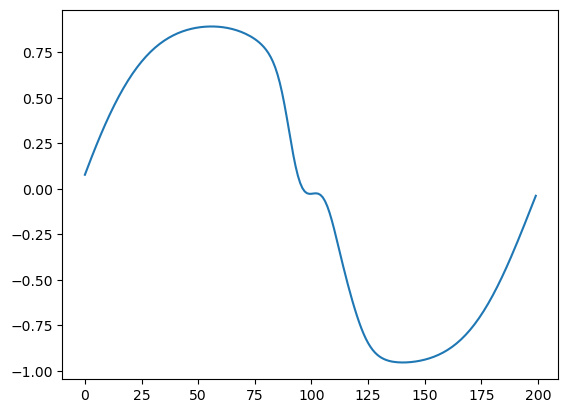

In [25]:
#I.C
plt.plot(y_pred_inverse[:,0])

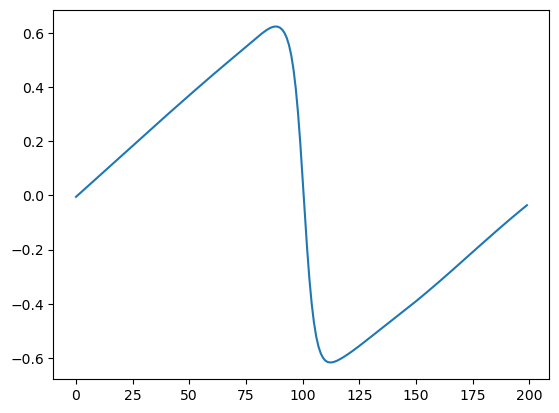

In [26]:
#I.C
plt.plot(y_pred_inverse[:,-1])

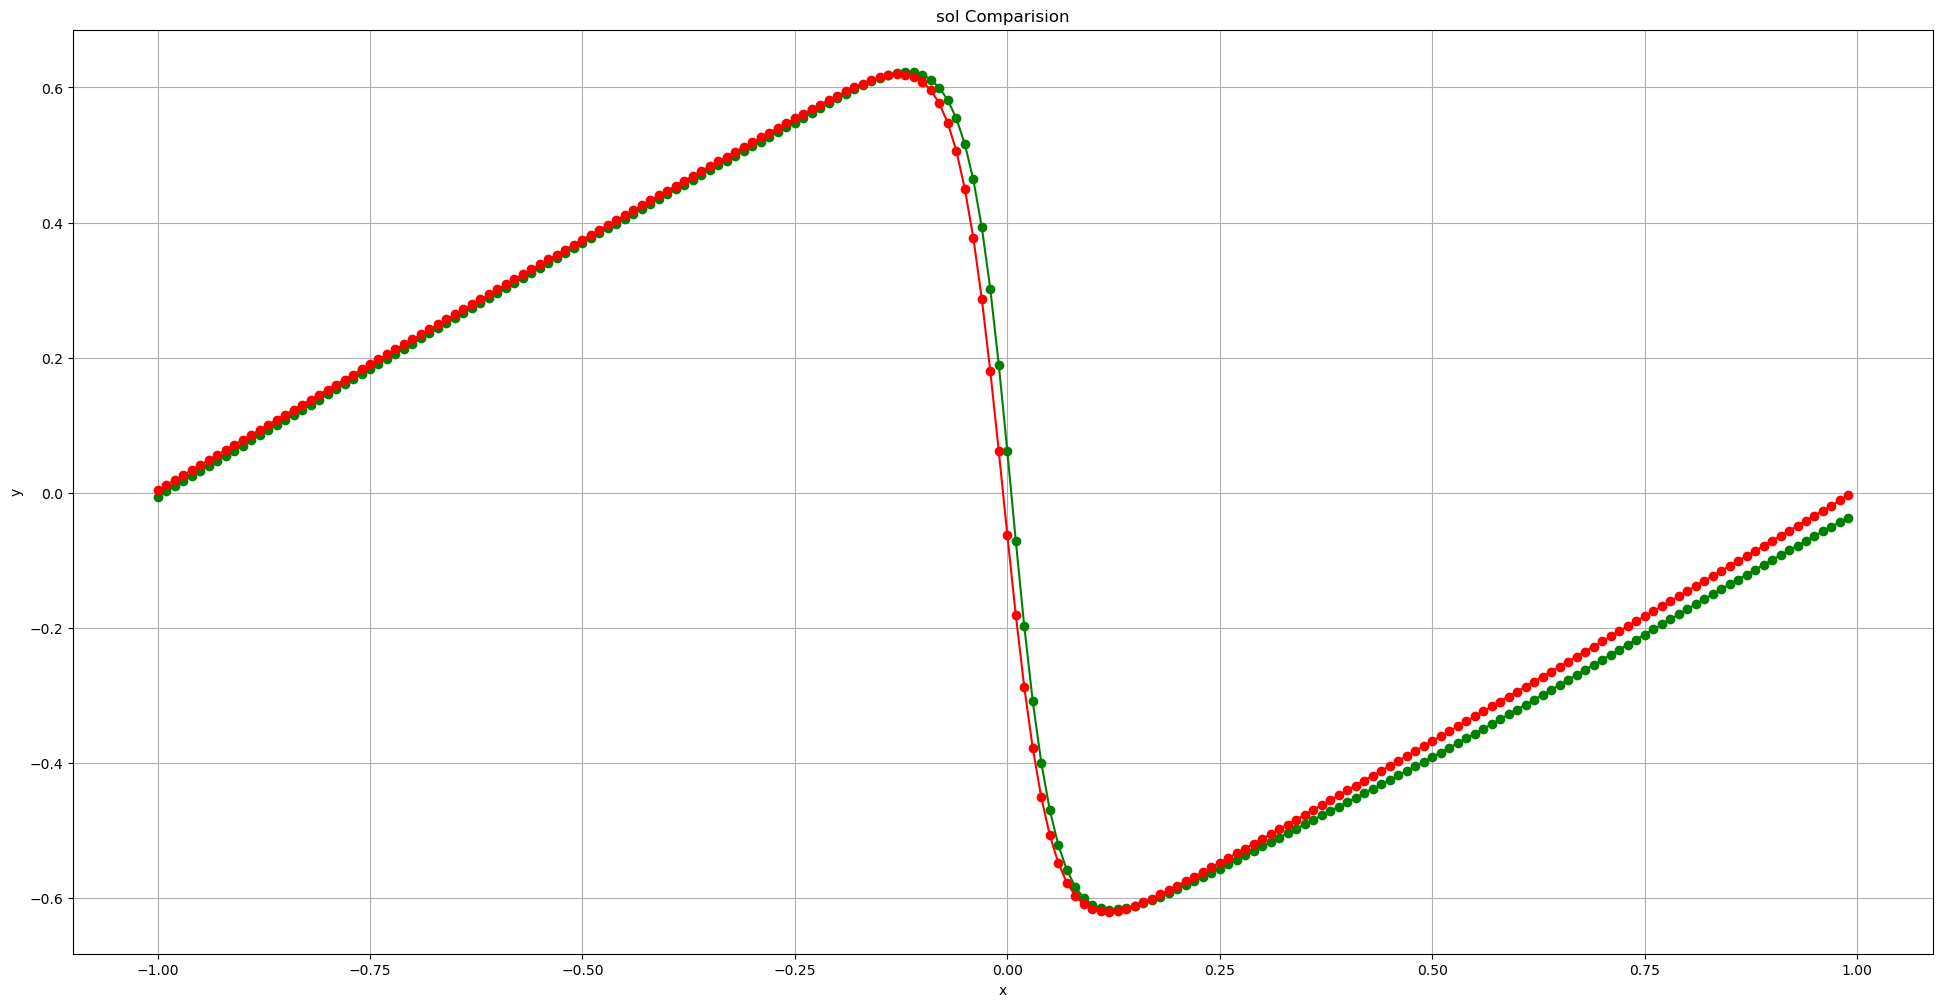

In [27]:
plt.figure(figsize=(24,12))
plt.plot(x, y_pred_inverse[:,-1], '-o', color = 'g') #IPINNs
plt.plot(x, uf[-1], '-o', color = 'r') #TVD
plt.title("sol Comparision")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

<Axes: >

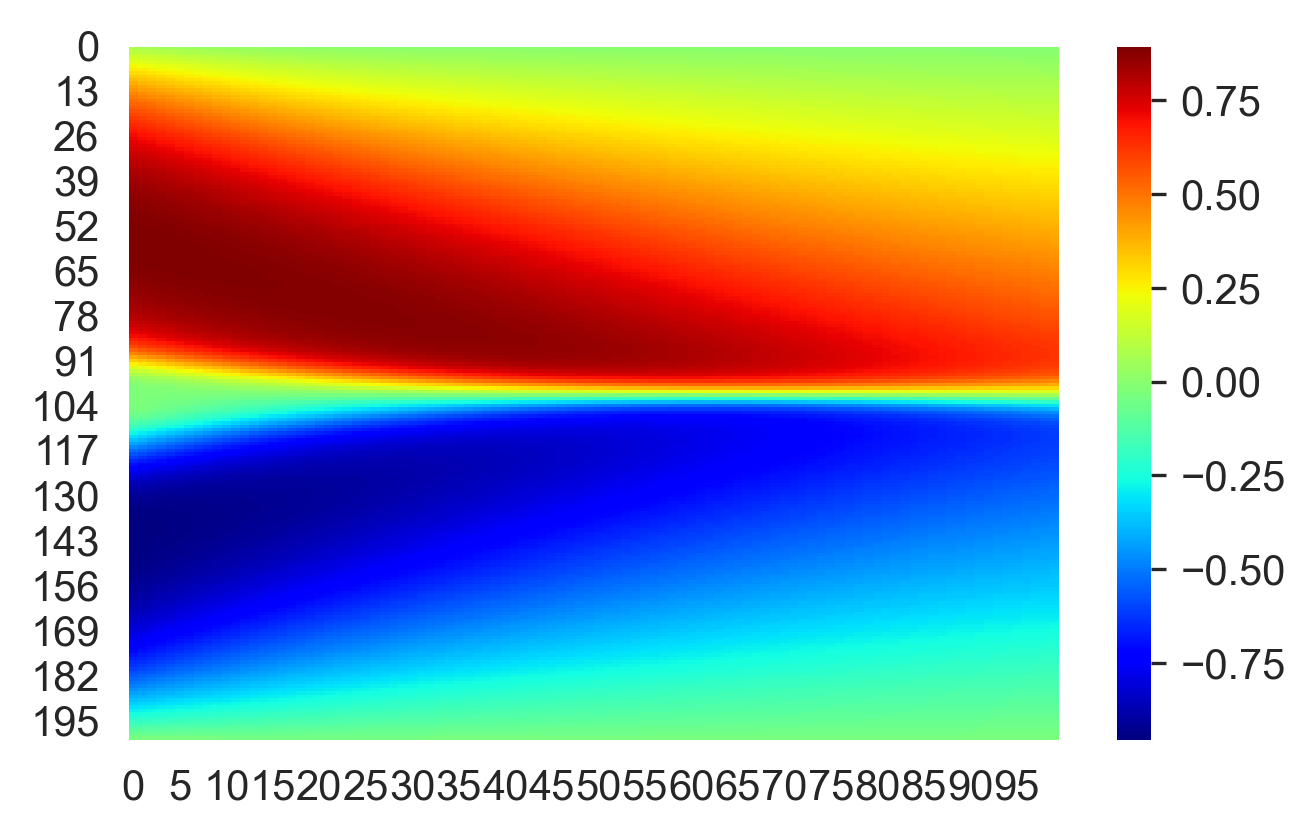

In [28]:
sns.set_style("white")
plt.figure(figsize=(5,3), dpi=300)
sns.heatmap(y_pred_inverse, cmap='jet')

In [29]:
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.net = torch.nn.Sequential(
            nn.Linear(2,20),
            nn.Tanh(),
            nn.Linear(20,30),
            nn.Tanh(),
            nn.Linear(30,30),
            nn.Tanh(),
            nn.Linear(30,20),
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,1)
        )
    
    def forward(self, x):
        out = self.net(x)
        return out

In [30]:
class Net:
    def __init__(self):
        device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        
        self.model = NN().to(device)
        
        # comp. domain 
        self.h = 0.1
        self.k = 0.1
        x = torch.arange(-1,1+self.h, self.h)
        t = torch.arange(0,1+self.k, self.k)
        
        self.X = torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T
        
        # train data
        bc1 = torch.stack(torch.meshgrid(x[0],t)).reshape(2,-1).T
        bc2 = torch.stack(torch.meshgrid(x[-1],t)).reshape(2,-1).T
        ic  = torch.stack(torch.meshgrid(x,t[0])).reshape(2,-1).T
        self.X_train = torch.cat([bc1, bc2, ic])
        
        y_bc1 = torch.zeros(len(bc1))
        y_bc2 = torch.zeros(len(bc2))
        y_ic  = -torch.sin(math.pi * ic[:,0])
        print(y_ic)
        
        self.y_train = torch.cat([y_bc1, y_bc2, y_ic])
        self.y_train = self.y_train.unsqueeze(1)
        
        self.X = self.X.to(device)
        self.y_train = self.y_train.to(device)
        self.X_train = self.X_train.to(device)
        self.X.requires_grad = True
        
        # optimizer setting
        self.adam =  torch.optim.Adam(self.model.parameters())
        #Limited-memory Broyden-Fletcher-Goldfarb-Shanno (L-BFGS)
        self.optimizer = torch.optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter = 50000,
            max_eval = 50000,
            history_size = 50,
            tolerance_grad = 1e-15,
            tolerance_change = 1.0* np.finfo(float).eps,
            line_search_fn ="strong_wolfe"
        )
        
        self.criterion = torch.nn.MSELoss()
        self.iter = 1
    
    def loss_func(self):
        self.adam.zero_grad()
        self.optimizer.zero_grad()
        
        y_pred = self.model(self.X_train)
        loss_data = self.criterion(y_pred,self.y_train)
        
        u = self.model(self.X)
        
        du_dX = torch.autograd.grad(
            u,
            self.X,
            grad_outputs = torch.ones_like(u),
            create_graph = True,
            retain_graph = True
        )[0]
        
        #print(du_dX)
        #print("xxxxxxxxxxxxxxxxxxxxxxxxx")
        #print(du_dX[0])
        
        du_dt = du_dX[:,1]
        du_dx = du_dX[:,0]
        
        du_dXX = torch.autograd.grad(
            du_dX,
            self.X,
            grad_outputs = torch.ones_like(du_dX),
            create_graph = True,
            retain_graph = True
        )[0]
        
        du_dxx = du_dXX[:,0]
        
        #loss_pde = self.criterion(du_dt + 1*u.squeeze()*du_dx , (0.01/math.pi) * du_dxx)
        loss_pde = self.criterion(du_dt + 1*u.squeeze()*du_dx , (0.02) * du_dxx)
        
        loss = loss_pde + loss_data
        loss.backward()
        
        if self.iter % 100 == 0:
            print(self.iter, loss.item())
        self.iter = self.iter+1
        
        return loss
    
    def train(self):
        self.model.train()
        for i in range(3000):
            self.adam.step(self.loss_func)
        self.optimizer.step(self.loss_func)
    
    def eval_(self):
        self.model.eval()

In [31]:
# training
net = Net()
net.train()
net.model.eval()

tensor([-8.7423e-08,  3.0902e-01,  5.8779e-01,  8.0902e-01,  9.5106e-01,
         1.0000e+00,  9.5106e-01,  8.0902e-01,  5.8779e-01,  3.0902e-01,
        -0.0000e+00, -3.0902e-01, -5.8779e-01, -8.0902e-01, -9.5106e-01,
        -1.0000e+00, -9.5106e-01, -8.0902e-01, -5.8779e-01, -3.0902e-01,
         8.7423e-08])
100 0.18076851963996887
200 0.06772945821285248
300 0.03919047862291336
400 0.030708350241184235
500 0.02268759161233902
600 0.01832471787929535
700 0.01438467763364315
800 0.012793900445103645
900 0.011151740327477455
1000 0.01015939936041832
1100 0.009427872486412525
1200 0.00850946269929409
1300 0.007998555898666382
1400 0.01296415738761425
1500 0.0069883959367871284
1600 0.007545464672148228
1700 0.006196381989866495
1800 0.006550973281264305
1900 0.005561337806284428
2000 0.005353775806725025
2100 0.005005583167076111
2200 0.004681894090026617
2300 0.004582779482007027
2400 0.004208986647427082
2500 0.008313548751175404
2600 0.003761852625757456
2700 0.0035178717225790024


NN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=1, bias=True)
  )
)

In [32]:
h = 0.01
k = 0.01

x = torch.arange(-1,1,h)
t = torch.arange(0,1,k)

X= torch.stack(torch.meshgrid(x,t)).reshape(2,-1).T
X= X.to(net.X.device)

model = net.model
model.eval()
with torch.no_grad():
    y_pred = model(X)
    y_pred = y_pred.reshape(len(x),len(t)).cpu().numpy()

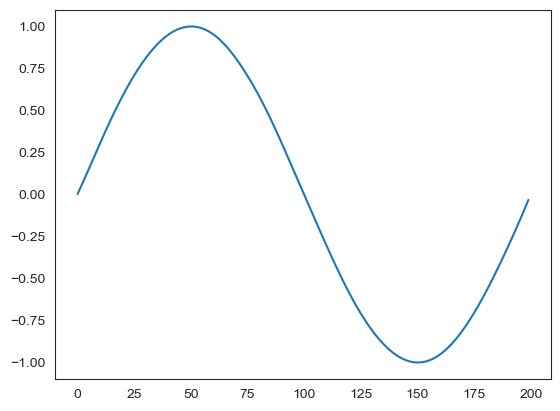

In [33]:
#I.C
plt.plot(y_pred[:,0])

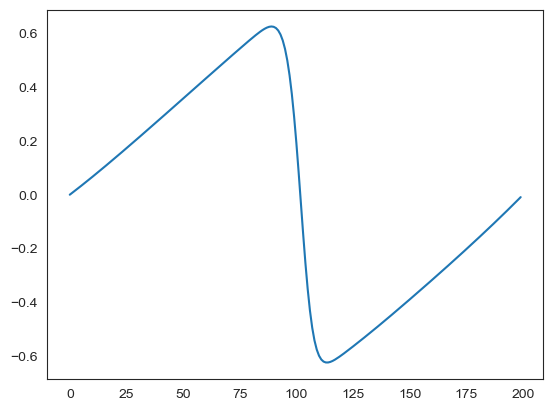

In [34]:
#final.sol
plt.plot(y_pred[:,-1])

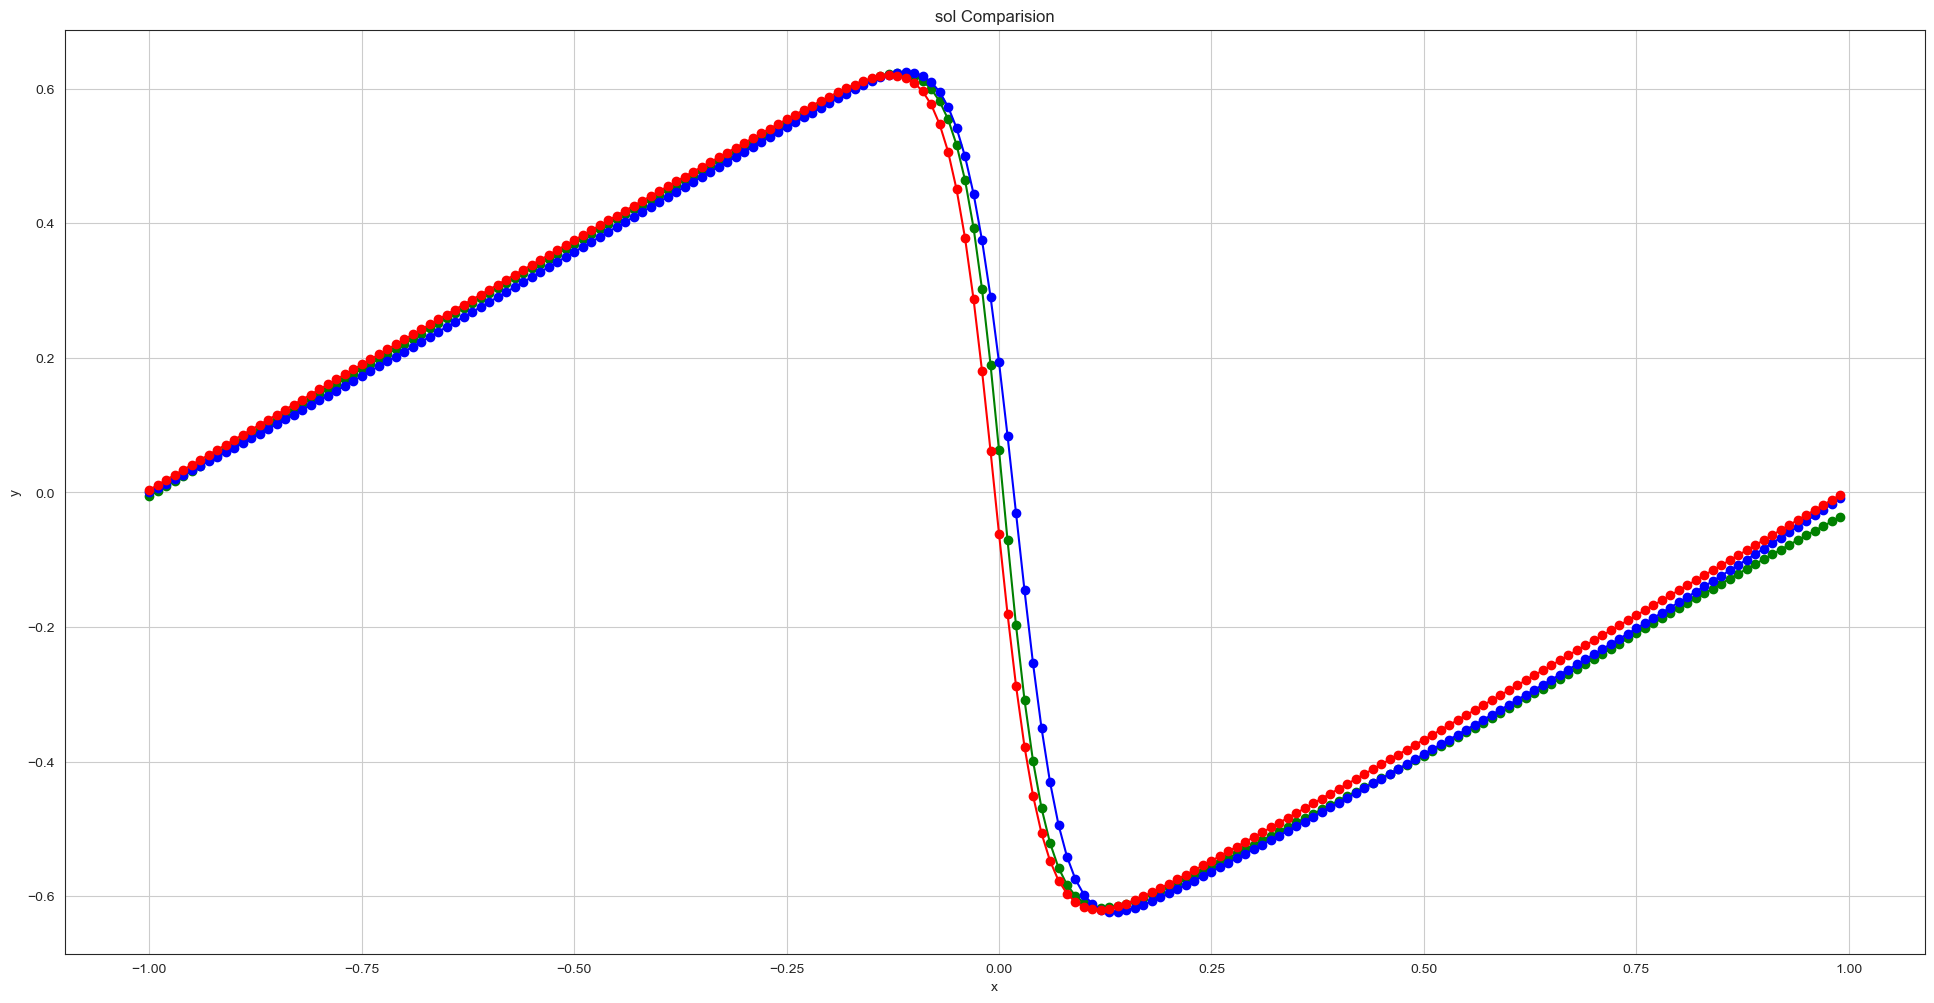

In [35]:
plt.figure(figsize=(24,12))

plt.plot(x, y_pred_inverse[:,-1], '-o', color = 'g') #IPINNs
plt.plot(x, y_pred[:,-1], '-o', color = 'b') #PINNs
plt.plot(x, uf[-1], '-o', color = 'r') #TVD

plt.title("sol Comparision")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()